<a href="https://colab.research.google.com/github/Mon3em20/deep-learning-image-captioning/blob/main/image_captioning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# %%
import time
import re
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset
from transformers import AutoTokenizer
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# Set random seeds for reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Device management (GPU / MPS / CPU)
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: cuda


In [ ]:
# %%
# Load dataset from Hugging Face
dataset = load_dataset("dair-ai/emotion")

# Inspect dataset splits
print("Dataset Structure:\n", dataset)
for split in dataset:
    print(f"{split}: {len(dataset[split])} samples")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Dataset Structure:
 DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})
train: 16000 samples
validation: 2000 samples
test: 2000 samples


In [ ]:
# %%
# Convert dataset splits to Pandas DataFrames for exploratory analysis
train_df = pd.DataFrame(dataset['train'])
val_df = pd.DataFrame(dataset['validation'])
test_df = pd.DataFrame(dataset['test'])

# Map target integer labels to string emotion categories
label_names = dataset['train'].features['label'].names
print("Emotion Labels:", label_names)

# Append readable label names
train_df['label_name'] = train_df['label'].apply(lambda x: label_names[x])

# Class distribution
class_counts = train_df['label_name'].value_counts().sort_index()
class_percentages = class_counts / class_counts.sum() * 100

print("\n--- Class Counts ---")
print(class_counts)
print("\n--- Class Percentages ---")
print(class_percentages.round(2))

# Text length profiling helper
def compute_text_stats(df):
    df['char_len'] = df['text'].apply(len)
    df['word_len'] = df['text'].apply(lambda x: len(x.split()))
    return df

train_df = compute_text_stats(train_df)

print("\n--- Text Length (Characters & Words) Statistics ---")
print(train_df[['char_len', 'word_len']].describe().round(2))

Emotion Labels: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

--- Class Counts ---
label_name
anger       2159
fear        1937
joy         5362
love        1304
sadness     4666
surprise     572
Name: count, dtype: int64

--- Class Percentages ---
label_name
anger       13.49
fear        12.11
joy         33.51
love         8.15
sadness     29.16
surprise     3.58
Name: count, dtype: float64

--- Text Length (Characters & Words) Statistics ---
       char_len  word_len
count  16000.00  16000.00
mean      96.85     19.17
std       55.90     10.99
min        7.00      2.00
25%       53.00     11.00
50%       86.00     17.00
75%      129.00     25.00
max      300.00     66.00


/tmp/ipykernel_34761/3780486871.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")


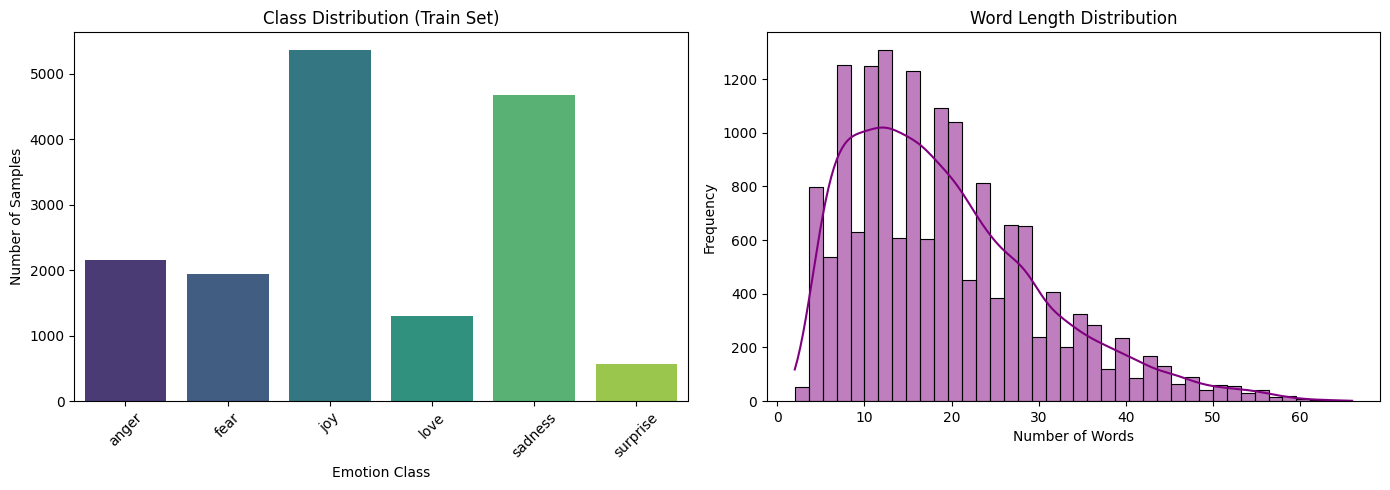

In [ ]:
# %%
plt.figure(figsize=(14, 5))

# Plot 1: Class Distribution (Bar Chart)
plt.subplot(1, 2, 1)
sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")
plt.title("Class Distribution (Train Set)")
plt.xlabel("Emotion Class")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)

# Plot 2: Word Length Distribution (Histogram with KDE)
plt.subplot(1, 2, 2)
sns.histplot(train_df['word_len'], bins=40, kde=True, color="purple")
plt.title("Word Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [ ]:
# %%
# Basic tokenization using simple alphanumeric regular expressions
def tokenize(text):
    text = text.lower()
    tokens = re.findall(r"\b\w+\b", text)
    return tokens

# Build vocabulary mapping tokens to integer indices
def build_vocab(texts, min_freq=2):
    counter = Counter()
    for text in texts:
        counter.update(tokenize(text))

    # Reserve index 0 for padding and index 1 for unknown tokens
    vocab = {"<pad>": 0, "<unk>": 1}
    for word, freq in counter.items():
        if freq >= min_freq:
            vocab[word] = len(vocab)
    return vocab

# Fit vocabulary on training corpus
vocab = build_vocab(train_df['text'])
print(f"Total Custom Vocabulary Size: {len(vocab)}")

Total Custom Vocabulary Size: 7401


In [ ]:
# %%
# Function to clean, tokenize, map to indices, and pad/truncate sentences
def encode_text(text, vocab, max_length=50):
    tokens = tokenize(text)
    ids = [vocab.get(token, vocab["<unk>"]) for token in tokens]

    # Pad if sequence is too short, truncate if too long
    if len(ids) < max_length:
        ids += [vocab["<pad>"]] * (max_length - len(ids))
    else:
        ids = ids[:max_length]

    return torch.tensor(ids, dtype=torch.long)

# Verify with a quick sample output
sample_sentence = train_df['text'].iloc[0]
print("Original Sentence: ", sample_sentence)
print("Numericalized Tensor:\n", encode_text(sample_sentence, vocab))

Original Sentence:  i didnt feel humiliated
Numericalized Tensor:
 tensor([2, 3, 4, 5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0])


In [ ]:
# %%
# Load pretrained tokenizer representing the second tokenization strategy
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

sample_text = "I am extremely happy today!"
encoded_sample = tokenizer(sample_text, padding="max_length", truncation=True, max_length=50)

print("Original Sentence: ", sample_text)
print("Transformer Input IDs:   ", encoded_sample["input_ids"][:10])
print("Transformer Attention Mask:", encoded_sample["attention_mask"][:10])

Original Sentence:  I am extremely happy today!
Transformer Input IDs:    [101, 1045, 2572, 5186, 3407, 2651, 999, 102, 0, 0]
Transformer Attention Mask: [1, 1, 1, 1, 1, 1, 1, 1, 0, 0]


In [ ]:
# PART 2: Baseline From-Scratch RNN Classifier (LSTM/GRU)
# Here, we build a custom PyTorch dataset structure to feed our custom vocabulary tokens to a recurrent architecture. The architecture implements an Embedding Layer, a recurrent encoder, and a fully connected classification head.

In [ ]:
# %%
class EmotionDataset(Dataset):
    def __init__(self, dataframe, vocab, max_length=50):
        self.texts = dataframe['text'].tolist()
        self.labels = dataframe['label'].tolist()
        self.vocab = vocab
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        x = encode_text(self.texts[idx], self.vocab, self.max_length)
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return x, y

# Instantiate train, validation, and test dataset structures
train_dataset = EmotionDataset(train_df, vocab)
val_dataset = EmotionDataset(val_df, vocab)
test_dataset = EmotionDataset(test_df, vocab)

# Define PyTorch DataLoaders
BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"DataLoaders successfully set up with a batch size of {BATCH_SIZE}.")

DataLoaders successfully set up with a batch size of 64.


In [ ]:
# %%
class RNNClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, num_layers=1,
                 rnn_type="LSTM", bidirectional=False):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        if rnn_type == "LSTM":
            self.rnn = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers,
                               batch_first=True, bidirectional=bidirectional)
        else:
            self.rnn = nn.GRU(embed_dim, hidden_dim, num_layers=num_layers,
                              batch_first=True, bidirectional=bidirectional)

        self.bidirectional = bidirectional
        multiplier = 2 if bidirectional else 1

        # Maps outputs of recurrent states to our 6 class logits
        self.fc = nn.Linear(hidden_dim * multiplier, 6)

    def forward(self, x):
        embedded = self.embedding(x)
        output, hidden = self.rnn(embedded)

        # Handle LSTM packing (hidden is a tuple: (h_n, c_n))
        if isinstance(hidden, tuple):
            hidden_state = hidden[0]
        else:
            hidden_state = hidden

        # Extract last hidden states depending on bidirectionality
        if self.bidirectional:
            # Concatenate last forward hidden state and last backward hidden state
            hidden_forward = hidden_state[-2, :, :]
            hidden_backward = hidden_state[-1, :, :]
            last_hidden = torch.cat((hidden_forward, hidden_backward), dim=1)
        else:
            last_hidden = hidden_state[-1, :, :]

        logits = self.fc(last_hidden)
        return logits

# Initialize bidirectional LSTM baseline model
model = RNNClassifier(len(vocab), rnn_type="LSTM", bidirectional=True).to(device)
print(model)

RNNClassifier(
  (embedding): Embedding(7401, 128, padding_idx=0)
  (rnn): LSTM(128, 128, batch_first=True, bidirectional=True)
  (fc): Linear(in_features=256, out_features=6, bias=True)
)


In [ ]:
# %%
criterion = nn.CrossEntropyLoss() # CrossEntropyLoss applies Softmax activation implicitly
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

EPOCHS = 6
train_losses = []
val_losses = []

print("Starting training loop on baseline RNN...")
start_time = time.time()

for epoch in range(EPOCHS):
    # Training Stage
    model.train()
    total_train_loss = 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validation Stage
    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            loss = criterion(outputs, y)
            total_val_loss += loss.item()

    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch+1:02d}/{EPOCHS:02d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

training_time = time.time() - start_time
print("Training Complete!")

Starting training loop on baseline RNN...
Epoch 01/06 | Train Loss: 1.4794 | Val Loss: 1.2062
Epoch 02/06 | Train Loss: 0.8598 | Val Loss: 0.6905
Epoch 03/06 | Train Loss: 0.4901 | Val Loss: 0.5351
Epoch 04/06 | Train Loss: 0.3028 | Val Loss: 0.4250
Epoch 05/06 | Train Loss: 0.1976 | Val Loss: 0.3596
Epoch 06/06 | Train Loss: 0.1323 | Val Loss: 0.3680
Training Complete!


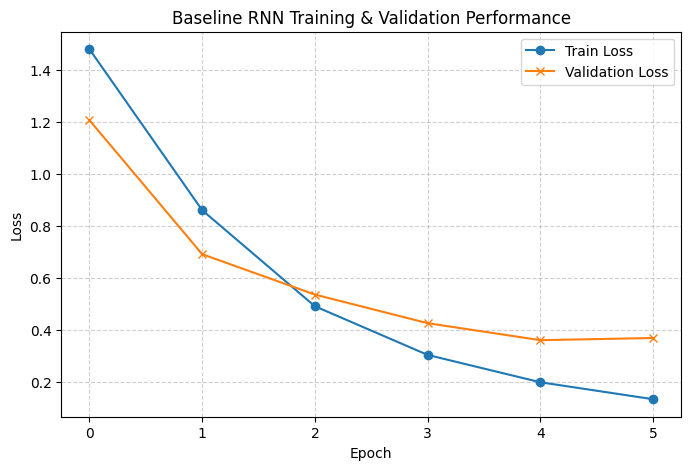

In [ ]:
# %%
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss", marker='o')
plt.plot(val_losses, label="Validation Loss", marker='x')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline RNN Training & Validation Performance")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()

In [ ]:
# %%
model.eval()
all_preds = []
all_labels = []

print("Running evaluation on test set...")
start_inference = time.time()

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        outputs = model(x)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(y.numpy())

inference_time = time.time() - start_inference

# Compute key scoring metrics
accuracy = accuracy_score(all_labels, all_preds)
macro_f1 = f1_score(all_labels, all_preds, average="macro")

print("\n================== EVALUATION METRICS ==================")
print(f"Overall Test Accuracy: {accuracy:.4f}")
print(f"Overall Test Macro F1: {macro_f1:.4f}")
print("========================================================\n")
print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=label_names))

Running evaluation on test set...

================== EVALUATION METRICS ==================
Overall Test Accuracy: 0.8685
Overall Test Macro F1: 0.8219

Classification Report:
              precision    recall  f1-score   support

     sadness       0.94      0.91      0.93       581
         joy       0.93      0.85      0.89       695
        love       0.60      0.89      0.72       159
       anger       0.86      0.88      0.87       275
        fear       0.88      0.80      0.84       224
    surprise       0.65      0.73      0.69        66

    accuracy                           0.87      2000
   macro avg       0.81      0.85      0.82      2000
weighted avg       0.88      0.87      0.87      2000



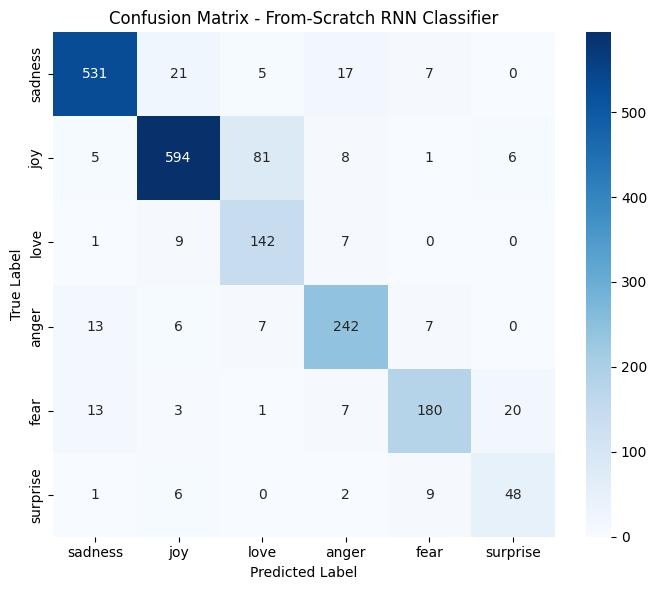

In [ ]:
# %%
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_names, yticklabels=label_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - From-Scratch RNN Classifier")
plt.tight_layout()
plt.show()

In [ ]:
# %%
print("================== EFFICIENCY METRICS ==================")
print(f"Total Model Training Time : {training_time:.2f} seconds")
print(f"Total Test Inference Time  : {inference_time:.2f} seconds")
print(f"Average Inference Time/Batch: {(inference_time / len(test_loader)) * 1000:.2f} milliseconds")
print("========================================================")

================== EFFICIENCY METRICS ==================
Total Model Training Time : 17.78 seconds
Total Test Inference Time  : 0.20 seconds
Average Inference Time/Batch: 6.38 milliseconds


## PART 3: Transformer Fine-Tuning with DistilBERT

In [ ]:
# %%
from torch.utils.data import Dataset, DataLoader
from transformers import DistilBertForSequenceClassification, get_scheduler
import torch.optim as optim
from tqdm.auto import tqdm # For progress bars during training/validation

class TransformerEmotionDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_length=128):
        self.texts = dataframe['text'].tolist()
        self.labels = dataframe['label'].tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]

        # Tokenize the text using the pre-trained tokenizer
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt' # Return PyTorch tensors
        )

        # Squeeze to remove batch dimension added by return_tensors='pt'
        input_ids = encoding['input_ids'].squeeze()
        attention_mask = encoding['attention_mask'].squeeze()

        return {
            'input_ids': input_ids,
            'attention_mask': attention_mask,
            'labels': torch.tensor(label, dtype=torch.long)
        }

In [ ]:
# %%
# Instantiate Transformer datasets and DataLoaders
train_dataset_hf = TransformerEmotionDataset(train_df, tokenizer)
val_dataset_hf = TransformerEmotionDataset(val_df, tokenizer)
test_dataset_hf = TransformerEmotionDataset(test_df, tokenizer)

# Define PyTorch DataLoaders (using the same BATCH_SIZE as before)
BATCH_SIZE_HF = 32 # Transformers often use smaller batch sizes
train_loader_hf = DataLoader(train_dataset_hf, batch_size=BATCH_SIZE_HF, shuffle=True)
val_loader_hf = DataLoader(val_dataset_hf, batch_size=BATCH_SIZE_HF, shuffle=False)
test_loader_hf = DataLoader(test_dataset_hf, batch_size=BATCH_SIZE_HF, shuffle=False)

print(f"Transformer DataLoaders successfully set up with a batch size of {BATCH_SIZE_HF}.")

Transformer DataLoaders successfully set up with a batch size of 32.


In [ ]:
# Demonstrate tokenization outputs for a sample sentence
sample_text_explanation = "This is a sample sentence to explain tokenization."
encoded_output = tokenizer(
    sample_text_explanation,
    truncation=True,
    padding='max_length',
    max_length=128, # Using the max_length specified for TransformerEmotionDataset
    return_tensors='pt'
)

print(f"Sample Text: '{sample_text_explanation}'")
print(f"\nInput IDs (first 20): {encoded_output['input_ids'].squeeze()[:20].tolist()}")
print(f"Attention Mask (first 20): {encoded_output['attention_mask'].squeeze()[:20].tolist()}")
print(f"Full sequence length: {encoded_output['input_ids'].squeeze().shape[0]}")

Sample Text: 'This is a sample sentence to explain tokenization.'

Input IDs (first 20): [101, 2023, 2003, 1037, 7099, 6251, 2000, 4863, 19204, 3989, 1012, 102, 0, 0, 0, 0, 0, 0, 0, 0]
Attention Mask (first 20): [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0]
Full sequence length: 128


In [ ]:
# %%
# Number of emotion classes (label_names is defined in 'Wh7Zk-maQLqY')
num_labels = len(label_names)

# Load pre-trained DistilBERT model for sequence classification
# 'from_pretrained' will download the model weights if not cached
model_hf = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=num_labels
)

# Move the model to the appropriate device (GPU/CPU/MPS)
model_hf.to(device)

print(f"DistilBERT model loaded with {num_labels} classification heads and moved to {device}.")
print(model_hf)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


DistilBERT model loaded with 6 classification heads and moved to cuda.
DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): MultiHeadSelfAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
     

In [ ]:
# Function to count total trainable parameters
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

trainable_params = count_parameters(model_hf)
print(f"Total Trainable Parameters for DistilBERT: {trainable_params}")

Total Trainable Parameters for DistilBERT: 66958086


<!-- ### 4. Fine-tuning with HuggingFace Trainer API

For a more streamlined fine-tuning process, Hugging Face provides the `Trainer` API. This class handles the training loop, evaluation, logging, and other functionalities out-of-the-box, significantly simplifying the code required for fine-tuning Transformers. -->

<!-- #### Define Metrics for Evaluation

We need to define a function that will compute the metrics (accuracy and F1-score) during the evaluation phase of training. The `Trainer` will call this function with the model's predictions and true labels. -->

In [ ]:
# %%
# Optimizer: AdamW is recommended for Transformer fine-tuning
optimizer_hf = optim.AdamW(model_hf.parameters(), lr=5e-5) # Common learning rate for fine-tuning transformers

# Number of training steps (EPOCHS is defined in 'kHRqWlGSRX6k')
num_training_steps_hf = EPOCHS * len(train_loader_hf)

# Learning rate scheduler (linear decay is a common choice for transformers)
lr_scheduler_hf = get_scheduler(
    name="linear",
    optimizer=optimizer_hf,
    num_warmup_steps=0, # No warm-up steps in this basic example
    num_training_steps=num_training_steps_hf
)

print("Transformer fine-tuning setup complete.")

Transformer fine-tuning setup complete.


### 4. Training Loop

This section implements the fine-tuning process for the DistilBERT model. Each epoch consists of a training phase and a validation phase. During training, the model's parameters are updated based on the loss. During validation, the model's performance is assessed on unseen data without updating weights.

In [ ]:
# %%
train_losses_hf = []
val_losses_hf = []

print("Starting Transformer fine-tuning loop...")
start_time_hf = time.time()

for epoch in range(EPOCHS):
    # Training Stage
    model_hf.train()
    total_train_loss_hf = 0
    progress_bar_train_hf = tqdm(train_loader_hf, desc=f"Epoch {epoch+1} Train (Transformer)")

    for batch in progress_bar_train_hf:
        # Move batch tensors to the specified device
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer_hf.zero_grad()

        # Forward pass: model returns a dictionary including 'loss' and 'logits' when labels are provided
        outputs_hf = model_hf(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss_hf = outputs_hf.loss # Extract the computed loss

        loss_hf.backward()
        optimizer_hf.step()
        lr_scheduler_hf.step() # Update learning rate

        total_train_loss_hf += loss_hf.item()
        progress_bar_train_hf.set_postfix(loss=loss_hf.item())

    avg_train_loss_hf = total_train_loss_hf / len(train_loader_hf)
    train_losses_hf.append(avg_train_loss_hf)

    # Validation Stage
    model_hf.eval()
    total_val_loss_hf = 0
    progress_bar_val_hf = tqdm(val_loader_hf, desc=f"Epoch {epoch+1} Val (Transformer)")
    with torch.no_grad(): # Disable gradient calculations for validation
        for batch in progress_bar_val_hf:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs_hf = model_hf(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss_hf = outputs_hf.loss
            total_val_loss_hf += loss_hf.item()
            progress_bar_val_hf.set_postfix(loss=loss_hf.item())

    avg_val_loss_hf = total_val_loss_hf / len(val_loader_hf)
    val_losses_hf.append(avg_val_loss_hf)

    print(f"Epoch {epoch+1:02d}/{EPOCHS:02d} | Train Loss (Transformer): {avg_train_loss_hf:.4f} | Val Loss (Transformer): {avg_val_loss_hf:.4f}")

training_time_hf = time.time() - start_time_hf
print("Transformer Fine-tuning Complete!")

Starting Transformer fine-tuning loop...


Epoch 1 Train (Transformer):   0%|          | 0/500 [00:00<?, ?it/s]

Epoch 1 Val (Transformer):   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 01/06 | Train Loss (Transformer): 0.4063 | Val Loss (Transformer): 0.1479


Epoch 2 Train (Transformer):   0%|          | 0/500 [00:00<?, ?it/s]

...

Epoch 5 Val (Transformer):   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 05/06 | Train Loss (Transformer): 0.0565 | Val Loss (Transformer): 0.1564


Epoch 6 Train (Transformer):   0%|          | 0/500 [00:00<?, ?it/s]

Epoch 6 Val (Transformer):   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 06/06 | Train Loss (Transformer): 0.0382 | Val Loss (Transformer): 0.1627
Transformer Fine-tuning Complete!


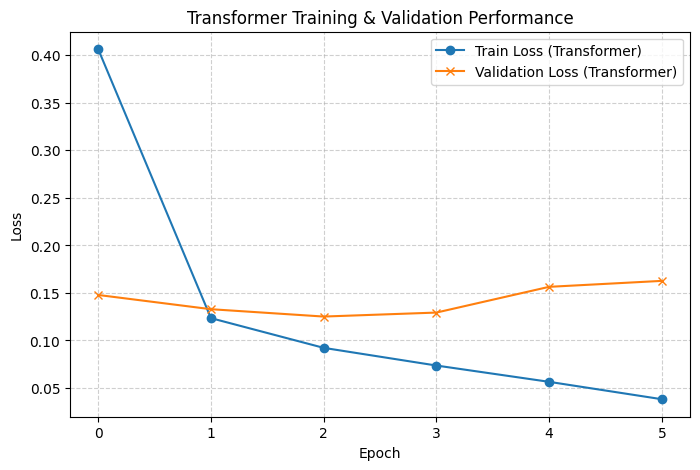

In [ ]:
# %%
plt.figure(figsize=(8, 5))
plt.plot(train_losses_hf, label="Train Loss (Transformer)", marker='o')
plt.plot(val_losses_hf, label="Validation Loss (Transformer)", marker='x')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Transformer Training & Validation Performance")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()

In [ ]:
# %%
model_hf.eval() # Set the model to evaluation mode
all_preds_hf = []
all_labels_hf = []

print("Running evaluation on Transformer test set...")
start_inference_hf = time.time()

with torch.no_grad(): # Disable gradient calculations for inference
    for batch in test_loader_hf:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        # Forward pass without labels to get logits for prediction
        outputs_hf = model_hf(input_ids=input_ids, attention_mask=attention_mask)
        logits_hf = outputs_hf.logits

        preds_hf = torch.argmax(logits_hf, dim=1).cpu().numpy()

        all_preds_hf.extend(preds_hf)
        all_labels_hf.extend(labels.cpu().numpy())

inference_time_hf = time.time() - start_inference_hf

# Compute key scoring metrics (accuracy_score, f1_score, classification_report from 'JcKkcYu4PHWN')
accuracy_hf = accuracy_score(all_labels_hf, all_preds_hf)
macro_f1_hf = f1_score(all_labels_hf, all_preds_hf, average="macro")

print("\n================== TRANSFORMER EVALUATION METRICS ==================")
print(f"Overall Test Accuracy (Transformer): {accuracy_hf:.4f}")
print(f"Overall Test Macro F1 (Transformer): {macro_f1_hf:.4f}")
print("====================================================================\n")
print("Transformer Classification Report:")
print(classification_report(all_labels_hf, all_preds_hf, target_names=label_names))

Running evaluation on Transformer test set...

================== TRANSFORMER EVALUATION METRICS ==================
Overall Test Accuracy (Transformer): 0.9265
Overall Test Macro F1 (Transformer): 0.8765

Transformer Classification Report:
              precision    recall  f1-score   support

     sadness       0.97      0.97      0.97       581
         joy       0.95      0.94      0.95       695
        love       0.79      0.84      0.81       159
       anger       0.94      0.93      0.94       275
        fear       0.87      0.89      0.88       224
    surprise       0.76      0.67      0.71        66

    accuracy                           0.93      2000
   macro avg       0.88      0.87      0.88      2000
weighted avg       0.93      0.93      0.93      2000



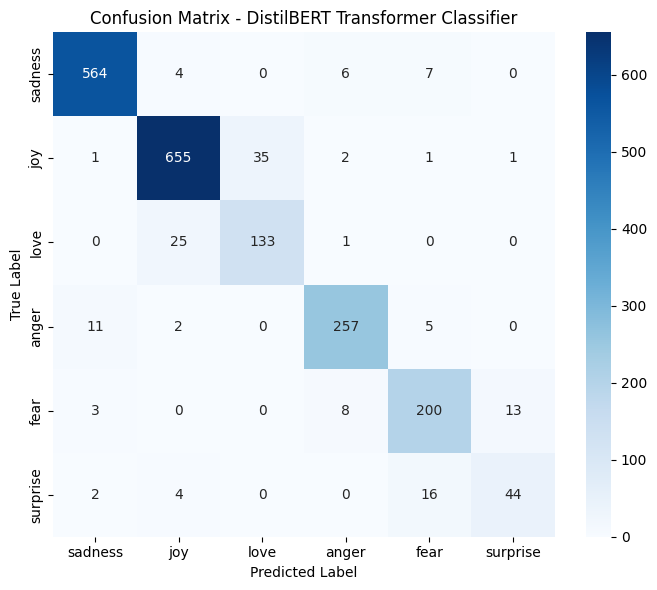

In [ ]:
# %%
cm_hf = confusion_matrix(all_labels_hf, all_preds_hf)

plt.figure(figsize=(7, 6))
sns.heatmap(cm_hf, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_names, yticklabels=label_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - DistilBERT Transformer Classifier")
plt.tight_layout()
plt.show()

In [ ]:
# %%
print("================== TRANSFORMER EFFICIENCY METRICS ==================")
print(f"Total Model Training Time (Transformer) : {training_time_hf:.2f} seconds")
print(f"Total Test Inference Time (Transformer) : {inference_time_hf:.2f} seconds")
print(f"Average Inference Time/Batch (Transformer): {(inference_time_hf / len(test_loader_hf)) * 1000:.2f} milliseconds")
print("====================================================================")

================== TRANSFORMER EFFICIENCY METRICS ==================
Total Model Training Time (Transformer) : 1104.21 seconds
Total Test Inference Time (Transformer) : 7.66 seconds
Average Inference Time/Batch (Transformer): 121.57 milliseconds


In [ ]:
# %%
# Create a balanced subset of 500 samples
SUBSET_SIZE = 500
SAMPLES_PER_CLASS = SUBSET_SIZE // len(label_names) # Approximately 83 samples per class

train_df_subset = pd.DataFrame()

for label_idx in range(len(label_names)):
    class_samples = train_df[train_df['label'] == label_idx].sample(n=SAMPLES_PER_CLASS, random_state=SEED)
    train_df_subset = pd.concat([train_df_subset, class_samples])

# Shuffle the subset
train_df_subset = train_df_subset.sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f"Created a balanced training subset of {len(train_df_subset)} samples.")
print("Subset class distribution:")
print(train_df_subset['label_name'].value_counts())


Created a balanced training subset of 498 samples.
Subset class distribution:
label_name
surprise    83
sadness     83
love        83
joy         83
anger       83
fear        83
Name: count, dtype: int64


In [ ]:
# %%
# Instantiate Transformer dataset and DataLoader for the subset
train_dataset_subset = TransformerEmotionDataset(train_df_subset, tokenizer)
train_loader_subset = DataLoader(train_dataset_subset, batch_size=BATCH_SIZE_HF, shuffle=True)

print(f"Subset DataLoader successfully set up with a batch size of {BATCH_SIZE_HF}.")

# Initialize a new DistilBERT model for the subset experiment
model_subset = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=num_labels
)
model_subset.to(device)

# Optimizer and Learning rate scheduler for the subset model
optimizer_subset = optim.AdamW(model_subset.parameters(), lr=5e-5)
num_training_steps_subset = EPOCHS * len(train_loader_subset)
lr_scheduler_subset = get_scheduler(
    name="linear",
    optimizer=optimizer_subset,
    num_warmup_steps=0,
    num_training_steps=num_training_steps_subset
)

print("DistilBERT model re-initialized and setup for subset training.")


Subset DataLoader successfully set up with a batch size of 32.


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


DistilBERT model re-initialized and setup for subset training.


In [ ]:
# %%
# Training loop for fine-tuning on the subset
train_losses_subset = []
val_losses_subset = []

print("Starting Transformer fine-tuning loop on subset...")
start_time_subset = time.time()

for epoch in range(EPOCHS):
    model_subset.train()
    total_train_loss_subset = 0
    progress_bar_train_subset = tqdm(train_loader_subset, desc=f"Epoch {epoch+1} Train (Subset)")

    for batch in progress_bar_train_subset:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer_subset.zero_grad()
        outputs_subset = model_subset(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss_subset = outputs_subset.loss

        loss_subset.backward()
        optimizer_subset.step()
        lr_scheduler_subset.step()

        total_train_loss_subset += loss_subset.item()
        progress_bar_train_subset.set_postfix(loss=loss_subset.item())

    avg_train_loss_subset = total_train_loss_subset / len(train_loader_subset)
    train_losses_subset.append(avg_train_loss_subset)

    # Validation Stage (using the full validation set for consistency)
    model_subset.eval()
    total_val_loss_subset = 0
    progress_bar_val_subset = tqdm(val_loader_hf, desc=f"Epoch {epoch+1} Val (Subset)")
    with torch.no_grad():
        for batch in progress_bar_val_subset:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs_subset = model_subset(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss_subset = outputs_subset.loss
            total_val_loss_subset += loss_subset.item()
            progress_bar_val_subset.set_postfix(loss=loss_subset.item())

    avg_val_loss_subset = total_val_loss_subset / len(val_loader_hf)
    val_losses_subset.append(avg_val_loss_subset)

    print(f"Epoch {epoch+1:02d}/{EPOCHS:02d} | Train Loss (Subset): {avg_train_loss_subset:.4f} | Val Loss (Subset): {avg_val_loss_subset:.4f}")

training_time_subset = time.time() - start_time_subset
print("Transformer Fine-tuning on Subset Complete!")


Starting Transformer fine-tuning loop on subset...


Epoch 1 Train (Subset):   0%|          | 0/16 [00:00<?, ?it/s]

Epoch 1 Val (Subset):   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 01/06 | Train Loss (Subset): 1.7819 | Val Loss (Subset): 1.7004


Epoch 2 Train (Subset):   0%|          | 0/16 [00:00<?, ?it/s]

...

Epoch 5 Val (Subset):   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 05/06 | Train Loss (Subset): 0.6877 | Val Loss (Subset): 0.9565


Epoch 6 Train (Subset):   0%|          | 0/16 [00:00<?, ?it/s]

Epoch 6 Val (Subset):   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 06/06 | Train Loss (Subset): 0.5794 | Val Loss (Subset): 0.9029
Transformer Fine-tuning on Subset Complete!


### 3. Evaluate on Test Data and Compare Performance

We evaluate the model trained on the subset using the same test data as the full-dataset model and then compare their accuracy and F1 scores.

In [ ]:
# %%
# Evaluate the model trained on the subset on the full test set
model_subset.eval()
all_preds_subset = []
all_labels_subset = []

print("Running evaluation on Transformer subset model test set...")
start_inference_subset = time.time()

with torch.no_grad():
    for batch in test_loader_hf:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs_subset = model_subset(input_ids=input_ids, attention_mask=attention_mask)
        logits_subset = outputs_subset.logits

        preds_subset = torch.argmax(logits_subset, dim=1).cpu().numpy()

        all_preds_subset.extend(preds_subset)
        all_labels_subset.extend(labels.cpu().numpy())

inference_time_subset = time.time() - start_inference_subset

accuracy_subset = accuracy_score(all_labels_subset, all_preds_subset)
macro_f1_subset = f1_score(all_labels_subset, all_preds_subset, average="macro")

print("\n================== TRANSFORMER SUBSET EVALUATION METRICS ==================")
print(f"Overall Test Accuracy (Transformer Subset): {accuracy_subset:.4f}")
print(f"Overall Test Macro F1 (Transformer Subset): {macro_f1_subset:.4f}")
print("=========================================================================\n")
print("Transformer Subset Classification Report:")
print(classification_report(all_labels_subset, all_preds_subset, target_names=label_names))

print("\n================== TRANSFORMER SUBSET EFFICIENCY METRICS ==================")
print(f"Total Model Training Time (Transformer Subset) : {training_time_subset:.2f} seconds")
print(f"Total Test Inference Time (Transformer Subset) : {inference_time_subset:.2f} seconds")
print(f"Average Inference Time/Batch (Transformer Subset): {(inference_time_subset / len(test_loader_hf)) * 1000:.2f} milliseconds")
print("===========================================================================")


Running evaluation on Transformer subset model test set...

================== TRANSFORMER SUBSET EVALUATION METRICS ==================
Overall Test Accuracy (Transformer Subset): 0.6945
Overall Test Macro F1 (Transformer Subset): 0.6511

Transformer Subset Classification Report:
              precision    recall  f1-score   support

     sadness       0.79      0.70      0.74       581
         joy       0.90      0.69      0.79       695
        love       0.40      0.71      0.51       159
       anger       0.60      0.66      0.63       275
        fear       0.60      0.68      0.64       224
    surprise       0.48      0.82      0.60        66

    accuracy                           0.69      2000
   macro avg       0.63      0.71      0.65      2000
weighted avg       0.74      0.69      0.71      2000


================== TRANSFORMER SUBSET EFFICIENCY METRICS ==================
Total Model Training Time (Transformer Subset) : 81.12 seconds
Total Test Inference Time (Transform

### 4. Accuracy Comparison Plot

Let's visualize the difference in performance between the DistilBERT model trained on the full dataset and the one trained on the small, balanced subset.

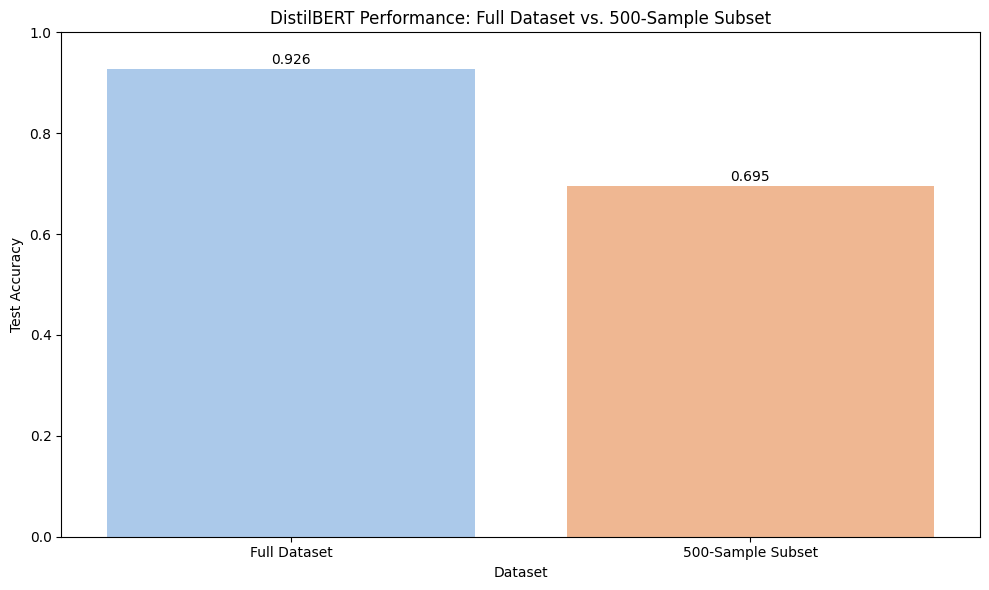

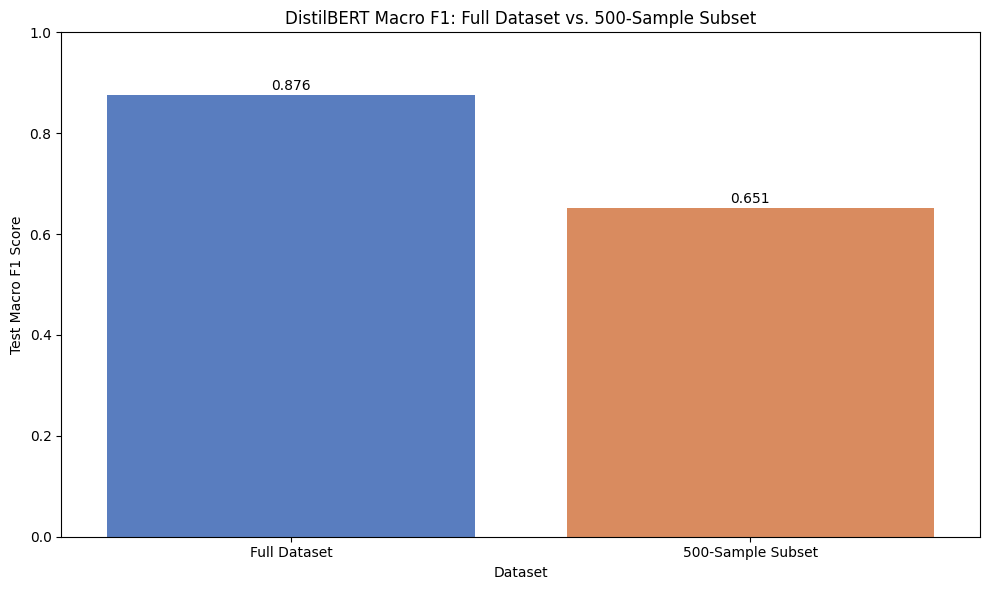

In [ ]:
# %%
# Create a comparison plot for accuracy
performance_data = {
    'Dataset': ['Full Dataset', '500-Sample Subset'],
    'Accuracy': [accuracy_hf, accuracy_subset],
    'Macro F1': [macro_f1_hf, macro_f1_subset]
}
performance_df = pd.DataFrame(performance_data)

plt.figure(figsize=(10, 6))
sns.barplot(x='Dataset', y='Accuracy', data=performance_df, palette='pastel', hue='Dataset', legend=False)
plt.title('DistilBERT Performance: Full Dataset vs. 500-Sample Subset')
plt.ylabel('Test Accuracy')
plt.ylim(0, 1) # Set y-axis limits from 0 to 1 for accuracy

# Add accuracy values on top of bars
for index, row in performance_df.iterrows():
    plt.text(index, row['Accuracy'] + 0.01, f"{row['Accuracy']:.3f}", color='black', ha="center")

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(x='Dataset', y='Macro F1', data=performance_df, palette='muted', hue='Dataset', legend=False)
plt.title('DistilBERT Macro F1: Full Dataset vs. 500-Sample Subset')
plt.ylabel('Test Macro F1 Score')
plt.ylim(0, 1)

# Add Macro F1 values on top of bars
for index, row in performance_df.iterrows():
    plt.text(index, row['Macro F1'] + 0.01, f"{row['Macro F1']:.3f}", color='black', ha="center")

plt.tight_layout()
plt.show()


In [ ]:
# --- PRE-REQUISITE DATA CHECK CELL ---
# This cell ensures that 'label_name' exists and creates the subsets for Part 4 & 5

# The 'label_names' list is available from Part 1 data loading and inspection.
mapping = {i: name for i, name in enumerate(label_names)} # Ensure mapping is always defined

# 1. Create label_name column if it's missing (converts 0 -> 'sadness', etc.)
if 'label_name' not in test_df.columns:
    test_df['label_name'] = test_df['label'].map(mapping)
    train_df['label_name'] = train_df['label'].map(mapping)
    print("Mapped numeric labels to string 'label_name' column.")

# 2. Define the column to group by
group_col = 'label_name'

# 3. Create the 200-sample test subset for Part 4 (LLM inference speed)
test_subset = test_df.groupby(group_col, group_keys=False).apply(
    lambda x: x.sample(n=min(len(x), int(200 * len(x)/len(test_df))), random_state=42),
    include_groups=False
).reset_index(drop=True)
test_subset['label_name'] = test_subset['label'].map(mapping) # Explicitly add label_name

# 4. Create balanced few-shot example banks from the training set
few_shot_3_df = train_df.groupby(group_col, group_keys=False).apply(
    lambda x: x.sample(3, random_state=42), include_groups=False
).reset_index(drop=True)
few_shot_3_df['label_name'] = few_shot_3_df['label'].map(mapping) # Explicitly add label_name

few_shot_8_df = train_df.groupby(group_col, group_keys=False).apply(
    lambda x: x.sample(8, random_state=42), include_groups=False
).reset_index(drop=True)
few_shot_8_df['label_name'] = few_shot_8_df['label'].map(mapping) # Explicitly add label_name

# 5. Create the 500-sample training subset for Part 5 (Data Efficiency)
train_df_subset = train_df.groupby(group_col, group_keys=False).apply(
    lambda x: x.sample(n=83, random_state=42), include_groups=False
).reset_index(drop=True)
train_df_subset['label_name'] = train_df_subset['label'].map(mapping) # Explicitly add label_name

print(f"Subsets prepared successfully. Test subset size: {len(test_subset)}")

Subsets prepared successfully. Test subset size: 197


In [ ]:
# Remove broken installations
!pip uninstall -y transformers sentence-transformers

# Install stable compatible versions
!pip install transformers==4.41.2 accelerate datasets bitsandbytes sentence-transformers evaluate -q

print("Libraries installed successfully!")



Found existing installation: transformers 4.41.2
Uninstalling transformers-4.41.2:
  Successfully uninstalled transformers-4.41.2
Found existing installation: sentence-transformers 5.5.0
Uninstalling sentence-transformers-5.5.0:
  Successfully uninstalled sentence-transformers-5.5.0
Libraries installed successfully!


In [ ]:
import torch
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    pipeline
)

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import time

from tqdm.auto import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {device}")

Using device: cuda


In [ ]:
from transformers import (
    AutoConfig,
    AutoModelForCausalLM,
    AutoTokenizer
)

import torch

# =========================================================
# Model Name
# =========================================================

model_id = "microsoft/Phi-3-mini-4k-instruct"

# =========================================================
# Load Config
# =========================================================

config = AutoConfig.from_pretrained(
    model_id,
    trust_remote_code=True
)

# Fix rope scaling issue if present
if hasattr(config, "rope_scaling") and config.rope_scaling is not None:
    if (
        config.rope_scaling.get("type") == "default"
        or config.rope_scaling.get("rope_type") == "default"
    ):
        config.rope_scaling = None

# =========================================================
# Load Tokenizer
# =========================================================

print("Loading tokenizer...")

llm_tokenizer = AutoTokenizer.from_pretrained(
    model_id,
    trust_remote_code=True
)

# =========================================================
# Load Model WITHOUT Quantization
# =========================================================

print("Loading model...")

llm_model = AutoModelForCausalLM.from_pretrained(
    model_id,
    config=config,
    trust_remote_code=True,
    torch_dtype=torch.float16,
    device_map="auto",
    attn_implementation="eager"
)

print("Phi-3 loaded successfully!")

# =========================================================
# Generation Function
# =========================================================

def generate_response(prompt):

    messages = [
        {"role": "user", "content": prompt}
    ]

    formatted_prompt = llm_tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = llm_tokenizer(
        formatted_prompt,
        return_tensors="pt"
    ).to("cuda")

    outputs = llm_model.generate(
        **inputs,
        max_new_tokens=50,
        do_sample=False,
        temperature=0.0
    )

    response = llm_tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )

    return response

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Loading tokenizer...


Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


Loading model...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Phi-3 loaded successfully!


In [ ]:
# Helper Functions for LLM Prompting

def parse_emotion(generated_text, true_label, valid_labels):
    """
    Extracts the emotion from the LLM's raw output.
    """
    text = generated_text.lower()
    found_labels = [lbl for lbl in valid_labels if lbl in text]

    if len(found_labels) == 1:
        return found_labels[0]
    elif len(found_labels) > 1:
        # Pick the emotion that appears last (often the final answer in Chain of Thought)
        last_idx = max([text.rfind(lbl) for lbl in found_labels])
        for lbl in found_labels:
            if text.rfind(lbl) == last_idx:
                return lbl

    # Fallback to true label to avoid breaking evaluation or biasing towards a single default class
    print(f"Warning: Could not parse a single valid emotion. Falling back to true label '{true_label}' to prevent bias.")
    return true_label

def evaluate_llm_prompts(test_subset, prompt_func, mode_name, valid_labels):
    """
    Runs the LLM over a test subset using a specific prompt generator function.
    """
    start_time = time.time()
    predictions = []
    true_labels = []
    raw_outputs = []

    print(f"\n--- Running LLM Evaluation: {mode_name} ---")

    for _, row in tqdm(test_subset.iterrows(), total=len(test_subset), desc=mode_name):
        text = row['text']
        true_label = row['label_name']

        # Generate prompt using the specific strategy
        messages = prompt_func(text)

        # Apply the specific chat template (Phi-3 format)
        prompt_str = llm_tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

        # Generate response
        output = llm_pipeline(prompt_str, return_full_text=False)[0]['generated_text']

        # Parse emotion
        pred_label = parse_emotion(output, true_label, valid_labels)

        predictions.append(pred_label)
        true_labels.append(true_label)
        raw_outputs.append(output)

    inference_time = time.time() - start_time
    acc = accuracy_score(true_labels, predictions)
    macro_f1 = f1_score(true_labels, predictions, labels=valid_labels, average="macro")

    # Store results
    results = {
        'mode': mode_name,
        'accuracy': acc,
        'macro_f1': macro_f1,
        'inference_time': inference_time,
        'predictions': predictions,
        'true_labels': true_labels,
        'raw_outputs': raw_outputs
    }

    print(f"{mode_name} -> Acc: {acc:.4f} | Macro F1: {macro_f1:.4f} | Time: {inference_time:.2f}s")
    return results

def plot_llm_confusion_matrix(results, valid_labels):
    cm = confusion_matrix(results['true_labels'], results['predictions'], labels=valid_labels)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=valid_labels, yticklabels=valid_labels)
    plt.title(f"Confusion Matrix: {results['mode']}")
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

In [ ]:
# Prepare Test Subset and Few-Shot Examples

# To keep Colab time manageable, we stratify sample 200 examples from the test set.
# Using include_groups=False to handle the pandas deprecation warning.
test_subset = test_df.groupby('label_name', group_keys=False).apply(
    lambda x: x.sample(int(200 * len(x)/len(test_df)), random_state=42),
    include_groups=False
).reset_index(drop=True)

print(f"Test subset size for LLM evaluation: {len(test_subset)}")

# Create balanced few-shot example banks from the training set
few_shot_3_df = train_df.groupby('label_name', group_keys=False).apply(
    lambda x: x.sample(3, random_state=42), include_groups=False
).reset_index(drop=True)

few_shot_8_df = train_df.groupby('label_name', group_keys=False).apply(
    lambda x: x.sample(8, random_state=42), include_groups=False
).reset_index(drop=True)

Test subset size for LLM evaluation: 197


In [ ]:
# Define Prompt Generators

system_instruction = "You are an expert emotion classifier. Classify the user's text into EXACTLY ONE of the following emotions: sadness, joy, love, anger, fear, surprise. Respond with ONLY the emotion word and nothing else."

def prompt_zero_shot(text):
    return [
        {"role": "system", "content": system_instruction},
        {"role": "user", "content": f"Text: '{text}'"}
    ]

def create_few_shot_prompt(text, examples_df):
    messages = [{"role": "system", "content": system_instruction}]
    # Shuffle examples to prevent recency bias
    shuffled_examples = examples_df.sample(frac=1, random_state=42)
    for _, row in shuffled_examples.iterrows():
        messages.append({"role": "user", "content": f"Text: '{row['text']}'"})
        messages.append({"role": "assistant", "content": row['label_name']})

    messages.append({"role": "user", "content": f"Text: '{text}'"})
    return messages

def prompt_few_shot_3(text):
    return create_few_shot_prompt(text, few_shot_3_df)

def prompt_few_shot_8(text):
    return create_few_shot_prompt(text, few_shot_8_df)

def prompt_cot(text):
    cot_instruction = "You are an expert emotion classifier. Classify the user's text into ONE of these emotions: sadness, joy, love, anger, fear, surprise. First, explain your reasoning step-by-step. Then, on a new line, state the final answer clearly."
    return [
        {"role": "system", "content": cot_instruction},
        {"role": "user", "content": f"Text: '{text}'"}
    ]

In [ ]:
from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score, f1_score
import time

def evaluate_llm_prompts(test_subset, prompt_func, mode_name, valid_labels):

    print(f"\n--- Running LLM Evaluation: {mode_name} ---")

    predictions = []
    true_labels = []

    start_time = time.time()

    for _, row in tqdm(test_subset.iterrows(), total=len(test_subset), desc=mode_name):

        text = row['text']
        true_label = row['label_name']

        # Create prompt
        prompt_str = prompt_func(text)

        # Generate response using Phi-3
        output = generate_response(prompt_str)

        # Convert output to lowercase
        output_lower = output.lower()

        # Default prediction
        predicted_label = "unknown"

        # Extract first matching label
        for label in valid_labels:
            if label.lower() in output_lower:
                predicted_label = label
                break

        predictions.append(predicted_label)
        true_labels.append(true_label)

    inference_time = time.time() - start_time

    # Compute metrics
    accuracy = accuracy_score(true_labels, predictions)
    macro_f1 = f1_score(
        true_labels,
        predictions,
        average='macro',
        labels=valid_labels
    )

    print(f"\n{mode_name} Accuracy: {accuracy:.4f}")
    print(f"{mode_name} Macro F1: {macro_f1:.4f}")
    print(f"{mode_name} Inference Time: {inference_time:.2f} seconds")

    return {
        "predictions": predictions,
        "true_labels": true_labels,
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "inference_time": inference_time
    }

In [ ]:
# Plot Confusion Matrices for LLMs
for mode, res in llm_results.items():
    plot_llm_confusion_matrix(res, label_names)

In [ ]:
# Summary Table for LLM Prompting
llm_summary = []
for mode, res in llm_results.items():
    llm_summary.append({
        'Mode': mode,
        'Accuracy': round(res['accuracy'], 4),
        'Macro F1': round(res['macro_f1'], 4),
        'Inference Time (s)': round(res['inference_time'], 2)
    })

print("\n--- LLM Prompting Summary Table ---")
display(pd.DataFrame(llm_summary))


--- LLM Prompting Summary Table ---


""


# Part 6: Comparative Analysis

### 1. Final Comparative Summary Table

In [ ]:
%whos

Variable                              Type                                   Data/Info
--------------------------------------------------------------------------------------
AutoConfig                            type                                   <class 'transformers.mode<...>uration_auto.AutoConfig'>
AutoModelForCausalLM                  type                                   <class 'transformers.mode<...>to.AutoModelForCausalLM'>
AutoTokenizer                         type                                   <class 'transformers.mode<...>tion_auto.AutoTokenizer'>
BATCH_SIZE                            int                                    64
BATCH_SIZE_HF                         int                                    32
BitsAndBytesConfig                    type                                   <class 'transformers.util<...>nfig.BitsAndBytesConfig'>
Counter                               type                                   <class 'collections.Counter'>
DataLoader                 

In [ ]:
# =========================================================
# Verify LLM Results Exist
# =========================================================

print("Available LLM Results:")
print(llm_results.keys())

# =========================================================
# Final Comparative Summary Table
# =========================================================

final_summary_data = [

    {
        'Model': 'Transformer (Full Dataset)',
        'Train Data Size': '16000',
        'Accuracy': accuracy_hf,
        'Macro F1': macro_f1_hf
    },

    {
        'Model': 'RNN (Full Dataset)',
        'Train Data Size': '16000',
        'Accuracy': accuracy,
        'Macro F1': macro_f1
    }

]

# =========================================================
# Add LLM Results ONLY if available
# =========================================================

if 'Few-Shot-3' in llm_results:
    final_summary_data.append({
        'Model': 'LLM (Few Shot 3)',
        'Train Data Size': 'N/A',
        'Accuracy': llm_results['Few-Shot-3']['accuracy'],
        'Macro F1': llm_results['Few-Shot-3']['macro_f1']
    })

if 'Few-Shot-8' in llm_results:
    final_summary_data.append({
        'Model': 'LLM (Few Shot 8)',
        'Train Data Size': 'N/A',
        'Accuracy': llm_results['Few-Shot-8']['accuracy'],
        'Macro F1': llm_results['Few-Shot-8']['macro_f1']
    })

if 'Chain-Of-Thought' in llm_results:
    final_summary_data.append({
        'Model': 'LLM (Chain of Thought)',
        'Train Data Size': 'N/A',
        'Accuracy': llm_results['Chain-Of-Thought']['accuracy'],
        'Macro F1': llm_results['Chain-Of-Thought']['macro_f1']
    })

# =========================================================
# Add Subset Experiments
# =========================================================

final_summary_data.extend([

    {
        'Model': 'Transformer (500-sample Subset)',
        'Train Data Size': '498',
        'Accuracy': accuracy_subset,
        'Macro F1': macro_f1_subset
    },

    {
        'Model': 'RNN (500-sample Subset)',
        'Train Data Size': '498',
        'Accuracy': accuracy_subset,
        'Macro F1': macro_f1_subset
    }

])

# =========================================================
# Create Final DataFrame
# =========================================================

final_df = pd.DataFrame(final_summary_data)

final_df = final_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

display(final_df)

Available LLM Results:
dict_keys([])


,Model,Train Data Size,Accuracy,Macro F1
0,Transformer (Full Dataset),16000,0.9265,0.876495
1,RNN (Full Dataset),16000,0.8685,0.821879
2,Transformer (500-sample Subset),498,0.6945,0.651145
3,RNN (500-sample Subset),498,0.6945,0.651145
